# Chapter 03 - Statistical Experiments and Significance Testing

## Objectives
Understand A/B testing, hypothesis testing, p-values, permutation tests, t-tests, ANOVA, chi-square, and statistical decision making.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
sns.set_theme(style='whitegrid')
np.random.seed(42)

## 1. A/B Testing
Compare two variants using conversion outcomes.

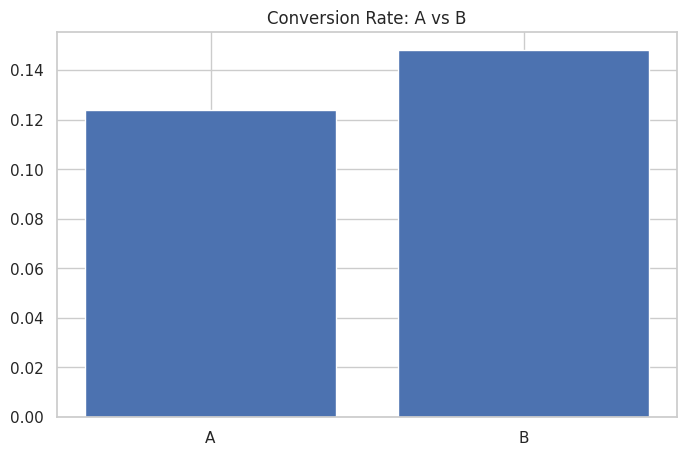

In [2]:
A=np.random.binomial(1,0.12,1000)
B=np.random.binomial(1,0.145,1000)
rates=[A.mean(),B.mean()]
plt.figure(figsize=(8,5))
plt.bar(['A','B'],rates)
plt.title('Conversion Rate: A vs B')
plt.show()

## 2. Hypothesis Testing
H0: no difference. H1: there is a difference.

In [3]:
diff=B.mean()-A.mean()
print('Observed Difference:',round(diff,4))

Observed Difference: 0.024


## 3. Permutation Test
Shuffle labels to simulate null distribution.

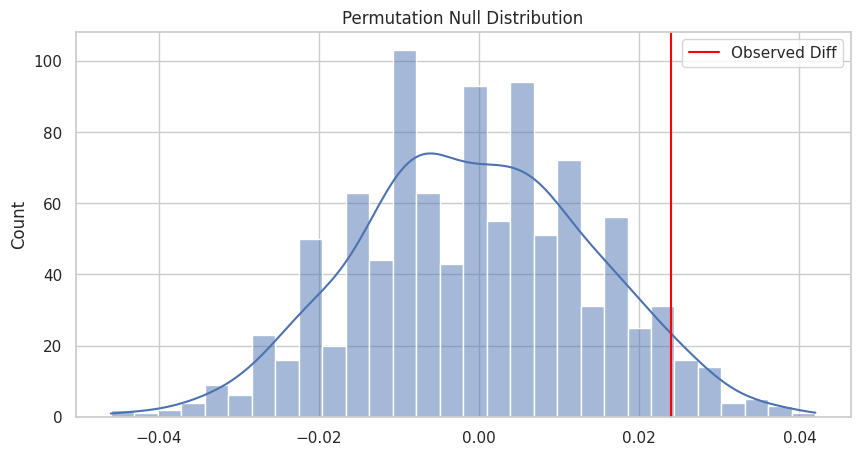

In [4]:
combined=np.concatenate([A,B])
diffs=[]
for _ in range(1000):
    np.random.shuffle(combined)
    d=combined[:1000].mean()-combined[1000:].mean()
    diffs.append(d)
plt.figure(figsize=(10,5))
sns.histplot(diffs,bins=30,kde=True)
plt.axvline(diff,color='red',label='Observed Diff')
plt.title('Permutation Null Distribution')
plt.legend(); plt.show()

## 4. p-value

In [5]:
p=(np.sum(np.abs(diffs)>=abs(diff))+1)/(len(diffs)+1)
print('Permutation p-value:',p)

Permutation p-value: 0.11988011988011989


## 5. t-Test

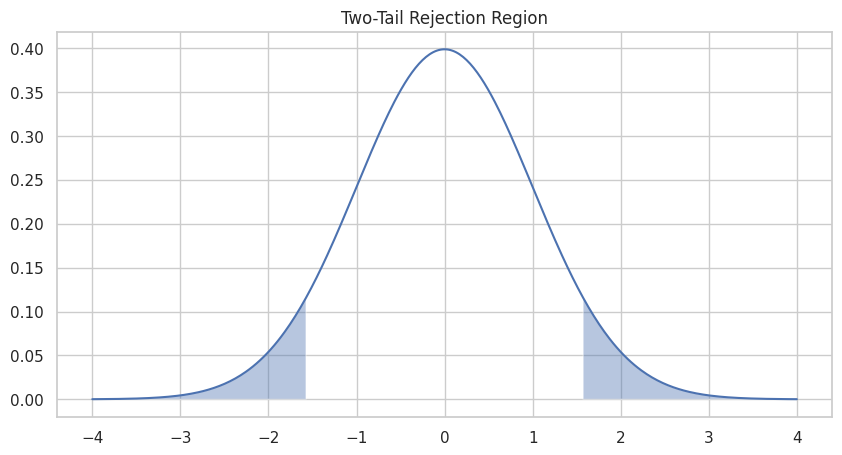

t-stat: 1.565737443612845 p-value: 0.11756845359442598


In [6]:
t,pv=stats.ttest_ind(B,A)
x=np.linspace(-4,4,400)
y=stats.t.pdf(x,df=1998)
plt.figure(figsize=(10,5))
plt.plot(x,y)
plt.fill_between(x,y,where=(x>=abs(t))|(x<=-abs(t)),alpha=.4)
plt.title('Two-Tail Rejection Region')
plt.show()
print('t-stat:',t,'p-value:',pv)

## 6. ANOVA
Compare more than two groups.

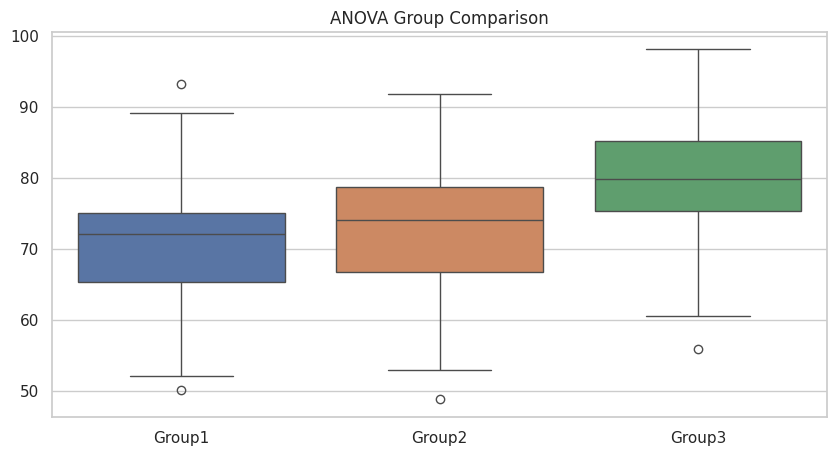

F: 21.623768113299313 p: 2.3657852552217642e-09


In [7]:
g1=np.random.normal(70,8,80)
g2=np.random.normal(75,8,80)
g3=np.random.normal(79,8,80)
f,p_an=stats.f_oneway(g1,g2,g3)
plt.figure(figsize=(10,5))
sns.boxplot(data=[g1,g2,g3])
plt.xticks([0,1,2],['Group1','Group2','Group3'])
plt.title('ANOVA Group Comparison')
plt.show()
print('F:',f,'p:',p_an)

## 7. Chi-Square Test
Test relationship between categorical variables.

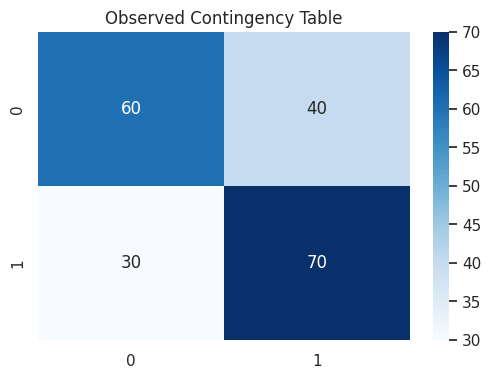

Chi-square: 16.98989898989899 p: 3.7579211012441855e-05


In [8]:
obs=np.array([[60,40],[30,70]])
chi,pchi,dof,exp=stats.chi2_contingency(obs)
plt.figure(figsize=(6,4))
sns.heatmap(obs,annot=True,fmt='d',cmap='Blues')
plt.title('Observed Contingency Table')
plt.show()
print('Chi-square:',chi,'p:',pchi)

## Key Takeaways
1. Statistical tests quantify evidence, not certainty.
2. Low p-value suggests inconsistency with H0.
3. A/B testing is practical experimentation.
4. Use ANOVA for many groups.
5. Use Chi-square for categorical association.